<a href="https://colab.research.google.com/github/banteamlak1888/Floridan-University-Fundamentals-AI-Trianing/blob/main/LOAN_APPROVAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LOAN APPROVAL PREDICTION PROJECT**

**STEP 1: IMPORT LIBRARIES**

In [ ]:
# ============================================================
# LOAN APPROVAL PREDICTION PROJECT
# Full Step-by-Step Machine Learning Workflow
# ============================================================

# -----------------------------
# STEP 1: IMPORT LIBRARIES
# -----------------------------
# pandas and numpy for data handling
import pandas as pd
import numpy as np

# matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn tools for preprocessing, model building, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Optional: to ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
#drive.mount('/content/drive')

**STEP 2: LOAD THE DATASET**

In [ ]:
# -----------------------------
# STEP 2: LOAD THE DATASET
# -----------------------------
# Replace the file path if needed
df = pd.read_csv("/content/sample_data/loan_approval_dataset.csv")

# Show first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

First 5 rows of the dataset:
   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value 

**STEP 3: UNDERSTAND THE DATA**

In [ ]:
# -----------------------------
# STEP 3: UNDERSTAND THE DATA
# -----------------------------
print("\nColumn names before cleaning:")
print(df.columns)

print("\nDataset information:")
print(df.info())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nStatistical summary:")
print(df.describe())



Column names before cleaning:
Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   i

**STEP 4: CLEAN COLUMN NAMES**

In [ ]:
# -----------------------------
# STEP 4: CLEAN COLUMN NAMES
# -----------------------------
# Some column names may contain leading/trailing spaces
# We remove them for easier handling
df.columns = df.columns.str.strip()

print("\nColumn names after cleaning:")
print(df.columns)


Column names after cleaning:
Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


**STEP 5: CHECK UNIQUE VALUES**

In [ ]:
# -----------------------------
# STEP 5: CHECK UNIQUE VALUES
# -----------------------------
# Useful for understanding categorical columns
print("\nUnique values in 'education':")
print(df['education'].unique())

print("\nUnique values in 'self_employed':")
print(df['self_employed'].unique())

print("\nUnique values in 'loan_status':")
print(df['loan_status'].unique())



Unique values in 'education':
[' Graduate' ' Not Graduate']

Unique values in 'self_employed':
[' No' ' Yes']

Unique values in 'loan_status':
[' Approved' ' Rejected']


**STEP 6: DROP UNNECESSARY COLUMN**

In [ ]:
# -----------------------------
# STEP 6: DROP UNNECESSARY COLUMN
# -----------------------------
# 'loan_id' is only an identifier and does not help prediction
df.drop("loan_id", axis=1, inplace=True)

print("\nDataset after dropping loan_id:")
print(df.head())



Dataset after dropping loan_id:
   no_of_dependents      education self_employed  income_annum  loan_amount  \
0                 2       Graduate            No       9600000     29900000   
1                 0   Not Graduate           Yes       4100000     12200000   
2                 3       Graduate            No       9100000     29700000   
3                 3       Graduate            No       8200000     30700000   
4                 5   Not Graduate           Yes       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_a

**STEP 7: HANDLE CATEGORICAL DATA**

In [ ]:
# -----------------------------
# STEP 7: HANDLE CATEGORICAL DATA
# -----------------------------
# Convert categorical text values into numeric values
# Machine learning models work better with numbers

# Label Encoders
le_education = LabelEncoder()
le_self_employed = LabelEncoder()
le_loan_status = LabelEncoder()

df['education'] = le_education.fit_transform(df['education'])
df['self_employed'] = le_self_employed.fit_transform(df['self_employed'])
df['loan_status'] = le_loan_status.fit_transform(df['loan_status'])

print("\nEncoded dataset sample:")
print(df.head())

print("\nEncoding for loan_status:")
for i, class_name in enumerate(le_loan_status.classes_):
    print(f"{class_name} --> {i}")


Encoded dataset sample:
   no_of_dependents  education  self_employed  income_annum  loan_amount  \
0                 2          0              0       9600000     29900000   
1                 0          1              1       4100000     12200000   
2                 3          0              0       9100000     29700000   
3                 3          0              0       8200000     30700000   
4                 5          1              1       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_va

**STEP 8: SEPARATE FEATURES AND TARGET**

In [ ]:
# -----------------------------
# STEP 8: SEPARATE FEATURES AND TARGET
# -----------------------------
# X = input features
# y = output/target
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("\nFeature columns:")
print(X.columns)

print("\nTarget column:")
print(y.head())


Feature columns:
Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

Target column:
0    0
1    1
2    1
3    1
4    1
Name: loan_status, dtype: int64


**STEP 9: TRAIN-TEST SPLIT**

In [ ]:
# -----------------------------
# STEP 9: TRAIN-TEST SPLIT
# -----------------------------
# 80% for training, 20% for testing
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (3415, 11)
Testing set shape: (854, 11)


**STEP 10: FEATURE SCALING**

In [ ]:
# -----------------------------
# STEP 10: FEATURE SCALING
# -----------------------------
# Scaling is especially important for:
# - Logistic Regression
# - KNN
# It makes all features have similar scale

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**STEP 11: TRAIN MULTIPLE MODELS**

In [ ]:
# -----------------------------
# STEP 11: TRAIN MULTIPLE MODELS
# -----------------------------
# We will train:
# 1. Logistic Regression
# 2. K-Nearest Neighbors
# 3. Decision Tree
# 4. Random Forest

models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Store results
results = {}

for name, model in models.items():
    print("\n" + "="*60)
    print(f"Training Model: {name}")

    # Use scaled data for Logistic Regression and KNN
    if name in ["Logistic Regression", "K-Nearest Neighbors"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # Tree-based models do not require scaling
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)


Training Model: Logistic Regression
Accuracy: 0.9227

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       531
           1       0.92      0.88      0.90       323

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.92       854
weighted avg       0.92      0.92      0.92       854


Confusion Matrix:
[[505  26]
 [ 40 283]]

Training Model: K-Nearest Neighbors
Accuracy: 0.8970

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       531
           1       0.88      0.85      0.86       323

    accuracy                           0.90       854
   macro avg       0.89      0.89      0.89       854
weighted avg       0.90      0.90      0.90       854


Confusion Matrix:
[[492  39]
 [ 49 274]]

Training Model: Decision Tree
Accuracy: 0.9719

Classification Report:
              precision    recall 

**STEP 12: COMPARE MODEL PERFORMANCE**

In [ ]:
# -----------------------------
# STEP 12: COMPARE MODEL PERFORMANCE
# -----------------------------
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

for model_name, acc in results.items():
    print(f"{model_name}: {acc:.4f}")


MODEL COMPARISON
Logistic Regression: 0.9227
K-Nearest Neighbors: 0.8970
Decision Tree: 0.9719
Random Forest: 0.9836


**STEP 13: VISUALIZE MODEL ACCURACY**

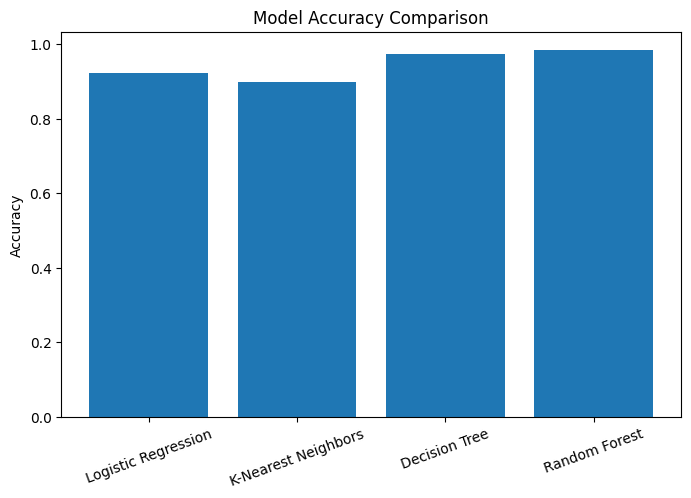

In [ ]:
# -----------------------------
# STEP 13: VISUALIZE MODEL ACCURACY
# -----------------------------
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()


**STEP 14: SELECT THE BEST MODEL**

In [ ]:
# -----------------------------
# STEP 14: SELECT THE BEST MODEL
# -----------------------------
best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)
print("Best Accuracy:", results[best_model_name])

best_model = models[best_model_name]


Best Model: Random Forest
Best Accuracy: 0.9836065573770492


**STEP 15: DISPLAY CONFUSION MATRIX**

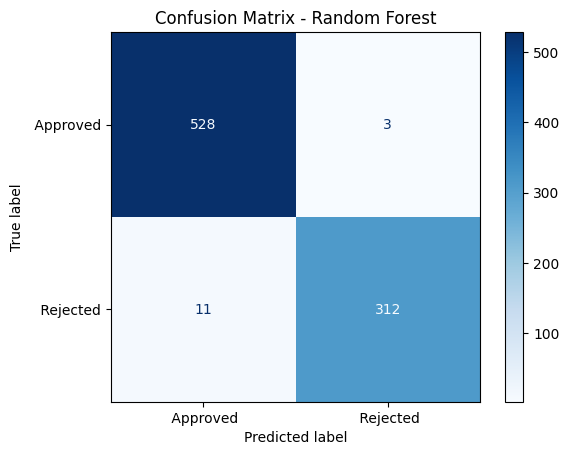

In [ ]:
# -----------------------------
# STEP 15: DISPLAY CONFUSION MATRIX
# -----------------------------
# Predict again using the correct data type
if best_model_name in ["Logistic Regression", "K-Nearest Neighbors"]:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_loan_status.classes_)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()



**STEP 16: FEATURE IMPORTANCE**


Feature Importance:
                     Feature  Importance
6                cibil_score    0.801152
5                  loan_term    0.064358
4                loan_amount    0.030672
3               income_annum    0.020317
9        luxury_assets_value    0.019399
8    commercial_assets_value    0.018403
7   residential_assets_value    0.017593
10          bank_asset_value    0.015068
0           no_of_dependents    0.007783
2              self_employed    0.002866
1                  education    0.002389


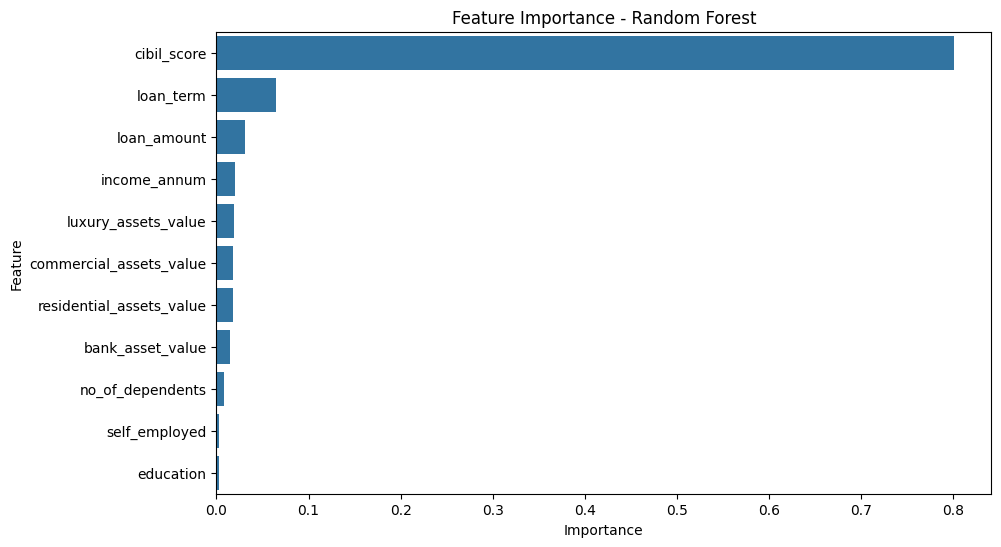

In [ ]:
# -----------------------------
# STEP 16: FEATURE IMPORTANCE
# -----------------------------
# Feature importance works best for tree-based models
if best_model_name in ["Decision Tree", "Random Forest"]:
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\nFeature Importance:")
    print(feature_importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.show()

**STEP 17: MAKE PREDICTION ON NEW DATA**

In [ ]:
# -----------------------------
# STEP 17: MAKE PREDICTION ON NEW DATA
# -----------------------------
# Example of a new applicant
new_applicant = pd.DataFrame([{
    'no_of_dependents': 2,
    'education': ' Graduate',
    'self_employed': ' No',
    'income_annum': 5000000,
    'loan_amount': 15000000,
    'loan_term': 10,
    'cibil_score': 750,
    'residential_assets_value': 6000000,
    'commercial_assets_value': 2000000,
    'luxury_assets_value': 3000000,
    'bank_asset_value': 4000000
}])

# Clean column names if needed
new_applicant.columns = new_applicant.columns.str.strip()

# Encode categorical values using same encoders
new_applicant['education'] = le_education.transform(new_applicant['education'])
new_applicant['self_employed'] = le_self_employed.transform(new_applicant['self_employed'])

# Predict using the best model
if best_model_name in ["Logistic Regression", "K-Nearest Neighbors"]:
    new_applicant_scaled = scaler.transform(new_applicant)
    prediction = best_model.predict(new_applicant_scaled)
else:
    prediction = best_model.predict(new_applicant)

# Convert numeric prediction back to original label
predicted_label = le_loan_status.inverse_transform(prediction)

print("\nPrediction for new applicant:")
print("Predicted Loan Status:", predicted_label[0])


Prediction for new applicant:
Predicted Loan Status:  Approved
